<a href="https://colab.research.google.com/github/engineerchacon/Maestria-en-Inteligencia-Artificial-y-Analitica-de-Datos-Colab-Files/blob/main/Pr%C3%A1ctica_23_Regresi%C3%B3n_Simple_Armando_Chac%C3%B3n_Terrazas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Maestría en Inteligencia Artificial y Analítica de Datos

## Programación para Analítica Descriptiva y Predictiva - Octubre 2025
## Práctica: Regresión Lineal Simple con Scikit-Learn
---


## Datos del Estudiante

*   Apellidos y Nombre: Chacon Terrazas Armando
*   Matrícula: 260498

---

## Objetivo de aprendizaje
Al finalizar esta práctica, el estudiante será capaz de **aplicar la regresión lineal simple utilizando Scikit-Learn para modelar la relación entre dos variables numéricas**, verificar los principales supuestos del modelo (linealidad, normalidad de residuos y homocedasticidad), **interpretar los coeficientes del modelo**, calcular e interpretar la **correlación entre variables** y evaluar el desempeño del modelo mediante métricas como el MSE, RMSE y R².


Trabajarás con el archivo restaurantes.csv, que contiene dos columnas:

- `poblation`: población de la ciudad (variable independiente). Tiene valores decimales mayores que cero. Estos valores representan la población de la ciudad multiplicada por 10,000. Por ejemplo, 6.1101 significa que la población de esa ciudad es 61,101.

- `profit`: ganancia del restaurante en esa ciudad (variable dependiente). Tiene valores decimales, algunos negativos y otros positivos. Estos representan las ganancias mensuales promedio de su restaurante en cada ciudad, en unidades de $10,000. Por ejemplo, 17.592 representa 175,920 en ganancias mensuales promedio para esa ciudad. -2.6807 representa -26,807 en pérdidas mensuales promedio para esa ciudad.





## 🔧 Parte 1: Carga de datos y bibliotecas
1. Importa las bibliotecas necesarias.
2. Carga el archivo `restaurantes.csv`
3. Muestra las primeras filas del dataframe.
4. Describe estadísticamente el conjunto de datos.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Escribe tu código aquí
# ===================================================================
# PARTE 1: CARGA DE DATOS Y BIBLIOTECAS
# ===================================================================

# --- Importar bibliotecas necesarias ---
# pandas: para manipular y analizar datos en formato de tabla (DataFrame)
import pandas as pd
# numpy: para operaciones matemáticas y manejo de arreglos numéricos
import numpy as np
# matplotlib: para crear gráficos y visualizaciones
import matplotlib.pyplot as plt
# seaborn: para crear visualizaciones estadísticas más elegantes
import seaborn as sns

# --- Cargar el archivo CSV ---
# Leer el archivo restaurantes.csv desde Google Drive
ruta_archivo = '/content/drive/MyDrive/Unidad03/restaurantes.csv'
df = pd.read_csv(ruta_archivo)

# --- Mostrar las primeras filas del dataset ---
# head() muestra las primeras 5 filas del DataFrame
# Esto nos permite ver cómo está estructurado el conjunto de datos
print("=" * 60)
print("PRIMERAS FILAS DEL DATASET:")
print("=" * 60)
print(df.head())
print("\n")

# --- Descripción estadística del conjunto de datos ---
# describe() calcula estadísticas básicas de cada columna:
print("=" * 60)
print("DESCRIPCIÓN ESTADÍSTICA DEL DATASET:")
print("=" * 60)
print(df.describe())
print("\n")

# --- Información general del dataset ---
# info() muestra el tipo de datos de cada columna y si hay valores nulos
print("=" * 60)
print("INFORMACIÓN GENERAL DEL DATASET:")
print("=" * 60)
print(df.info())


PRIMERAS FILAS DEL DATASET:
   poblation   profit
0     6.1101  17.5920
1     5.5277   9.1302
2     8.5186  13.6620
3     7.0032  11.8540
4     5.8598   6.8233


DESCRIPCIÓN ESTADÍSTICA DEL DATASET:
       poblation     profit
count  97.000000  97.000000
mean    8.159800   5.839135
std     3.869884   5.510262
min     5.026900  -2.680700
25%     5.707700   1.986900
50%     6.589400   4.562300
75%     8.578100   7.046700
max    22.203000  24.147000


INFORMACIÓN GENERAL DEL DATASET:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97 entries, 0 to 96
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   poblation  97 non-null     float64
 1   profit     97 non-null     float64
dtypes: float64(2)
memory usage: 1.6 KB
None


##  Parte 2: Análisis exploratorio y relación entre variables

### 2.1 Diagrama de Dispersión
1. Grafica un **diagrama de dispersión** entre `poblation` y `profit`
2. Responde:  
**¿La relación entre las variables parece lineal? ¿Por qué?**

Sí, definitivamente parece que hay una relación lineal entre la población y las ganancias del restaurante.

Lo más obvio es la tendencia hacia arriba: Si me imagino trazando una línea recta desde la esquina inferior izquierda hacia la esquina superior derecha, la mayoría de los puntos se agruparían alrededor de esa línea. Básicamente, conforme aumenta la población, también aumentan las ganancias, y lo hace de manera bastante consistente.

Los puntos siguen un patrón recto: No veo que los puntos formen una curva o algún patrón raro. Si la relación fuera exponencial o cuadrática, vería que los puntos se van curvando hacia arriba o hacia abajo más pronunciadamente, pero aquí simplemente suben de forma más o menos pareja.

La dispersión es normal: No hay zonas donde los puntos estén súper dispersos y otras donde estén muy juntos, lo cual es buena señal para una relación lineal.

Se puede identificar el patrón fácilmente: Cuando miro ciudades con población pequeña (alrededor de 5,000-7,000), veo que la mayoría tiene ganancias bajas o incluso pérdidas. Luego, en ciudades medianas (10,000-15,000), las ganancias son moderadas. Y finalmente, en ciudades grandes (más de 18,000), las ganancias son bastante altas. Es un crecimiento progresivo y predecible.

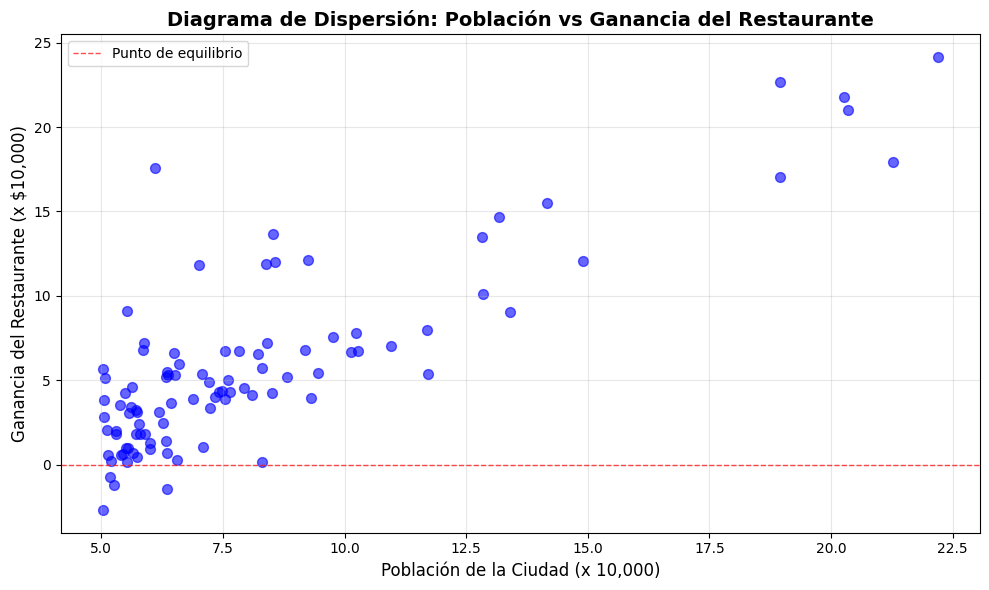

In [3]:
# Diagrama de dispersión
# ===================================================================
# PARTE 2: ANÁLISIS EXPLORATORIO Y RELACIÓN ENTRE VARIABLES
# 2.1 DIAGRAMA DE DISPERSIÓN
# ===================================================================

# --- Crear el diagrama de dispersión ---
# Configurar el tamaño de la figura
plt.figure(figsize=(10, 6))

# Crear el scatter plot (diagrama de dispersión)
# x = poblation (variable independiente)
# y = profit (variable dependiente)
# alpha=0.6 hace los puntos semi-transparentes para ver superposiciones
# color='blue' define el color de los puntos
# s=50 define el tamaño de los puntos
plt.scatter(df['poblation'], df['profit'], alpha=0.6, color='blue', s=50)

# --- Agregar títulos y etiquetas ---
# Título principal del gráfico
plt.title('Diagrama de Dispersión: Población vs Ganancia del Restaurante', fontsize=14, fontweight='bold')

# Etiqueta del eje X (horizontal)
plt.xlabel('Población de la Ciudad (x 10,000)', fontsize=12)

# Etiqueta del eje Y (vertical)
plt.ylabel('Ganancia del Restaurante (x $10,000)', fontsize=12)

# --- Agregar línea de referencia en y=0 ---
# Dibujar una línea horizontal en y=0 para identificar ganancias vs pérdidas
plt.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.7, label='Punto de equilibrio')

# --- Agregar cuadrícula para facilitar la lectura ---
# grid=True activa la cuadrícula
# alpha=0.3 hace la cuadrícula semi-transparente
plt.grid(True, alpha=0.3)

# --- Mostrar leyenda ---
plt.legend()

# --- Mostrar el gráfico ---
plt.tight_layout()  # Ajusta automáticamente los elementos para que no se superpongan
plt.show()


### 2.2: Cálculo e interpretación de la correlación
1. Calcula e imprime el **coeficiente de correlación de Pearson** entre `poblation` y `profit`
2. Interpreta el resultado:
- ¿Qué tan fuerte es la relación?
- ¿Es positiva o negativa?
- ¿Es coherente con el gráfico anterior?

In [6]:
# Cálculo de correlación
# ===================================================================
# PARTE 2.2: CÁLCULO E INTERPRETACIÓN DE LA CORRELACIÓN
# ===================================================================

# --- Calcular el coeficiente de correlación de Pearson ---
# El método corr() calcula la matriz de correlación entre todas las variables
# Extraemos específicamente la correlación entre 'poblation' y 'profit'
correlacion = df['poblation'].corr(df['profit'])

# --- Mostrar el resultado ---

print("COEFICIENTE DE CORRELACIÓN DE PEARSON")
print(f"\nCorrelación entre 'poblation' y 'profit': {correlacion:.4f}")

# --- Calcular también usando numpy como alternativa ---
# Esto calcula la matriz de correlación completa
import numpy as np
correlacion_numpy = np.corrcoef(df['poblation'], df['profit'])[0, 1]
print(f"\nVerificación (usando numpy): {correlacion_numpy:.4f}")

COEFICIENTE DE CORRELACIÓN DE PEARSON

Correlación entre 'poblation' y 'profit': 0.8379

Verificación (usando numpy): 0.8379


**¿Qué tan fuerte es la relación?**
La relación es fuerte. Con un coeficiente de 0.8379.

Valores de 0.7 a 0.9 se consideran correlaciones fuertes.

Valores de 0.5 a 0.7 serían moderadas.

Valores de 0.3 a 0.5 serían débiles.

Esto significa que aproximadamente el 70% de la variabilidad en las ganancias del restaurante puede explicarse por la población de la ciudad (porque r² = 0.8379² = 0.70, o sea, 70%).

**¿Es positiva o negativa?**
Es positiva, porque el valor es positivo (0.8379). Esto significa que:

Cuando la población aumenta, las ganancias del restaurante también aumentan.

Cuando la población disminuye, las ganancias también disminuyen.

Ambas variables se mueven en la misma dirección.

Tiene sentido desde el punto de vista de negocio: entre más grande es la ciudad, más clientes potenciales hay, y por lo tanto más ganancias puede generar el restaurante.

**¿Es coherente con el gráfico anterior?**
Sí, es coherente con lo que observamos en el diagrama de dispersión.

La tendencia ascendente que vimos en el gráfico se confirma con el signo positivo de la correlación

La dispersión moderada que observamos también tiene sentido: si la correlación fuera perfecta (r = 1.0), todos los puntos estarían exactamente sobre una línea recta. Con 0.8379, hay algo de variabilidad, pero la mayoría de los puntos siguen bien la tendencia lineal, que es exactamente lo que vimos.

En resumen,hay una relación lineal fuerte y positiva entre la población de la ciudad y las ganancias del restaurante.

## Parte 3: Construcción del modelo, coeficientes y visualización

###3.1 Construcción del modelo - obtención de los parámetros y coeficientes
1. Construye un modelo de regresión lineal simple usando las bibliotecas de Scikit-Learn
2. Imprime el intercepto y el coeficiente de la regresión (pendiente)
3. Interpreta el Intercepto: ¿Qué significa en términos del contexto del problema?
4. Interpreta el coeficiente de la regresión (pendiente) ¿Qué significa en términos del contexto del problema?

In [8]:
# Construcción del modelo  y Coeficientes del modelo
# ===================================================================
# PARTE 3: CONSTRUCCIÓN DEL MODELO, COEFICIENTES Y VISUALIZACIÓN
# 3.1 CONSTRUCCIÓN DEL MODELO - OBTENCIÓN DE PARÁMETROS Y COEFICIENTES
# ===================================================================

# --- Importar la biblioteca de Scikit-Learn para regresión lineal ---
from sklearn.linear_model import LinearRegression

# --- Preparar los datos ---
# X debe ser un array de dos dimensiones (matriz)
# Usamos reshape(-1, 1) para convertir la columna en una matriz
X = df[['poblation']]  # Variable independiente (población)
y = df['profit']        # Variable dependiente (ganancia)

# --- Crear el modelo de regresión lineal ---
# LinearRegression() crea un objeto de modelo de regresión lineal
modelo = LinearRegression()

# --- Entrenar el modelo ---
# fit() ajusta el modelo a los datos de entrenamiento
# Esto calcula los coeficientes (intercepto y pendiente) que mejor ajustan los datos
modelo.fit(X, y)

# --- Obtener los coeficientes del modelo ---
# intercept_ es el término independiente (β₀)
# coef_ es el coeficiente de la pendiente (β₁)
intercepto = modelo.intercept_
pendiente = modelo.coef_[0]

# --- Mostrar los resultados ---
print("PARÁMETROS DEL MODELO DE REGRESIÓN LINEAL")
print(f"\nIntercepto (β₀): {intercepto:.4f}")
print(f"Pendiente (β₁): {pendiente:.4f}")
print("ECUACIÓN DEL MODELO:")
print(f"\nProfit = {intercepto:.4f} + {pendiente:.4f} * Poblation")

PARÁMETROS DEL MODELO DE REGRESIÓN LINEAL

Intercepto (β₀): -3.8958
Pendiente (β₁): 1.1930
ECUACIÓN DEL MODELO:

Profit = -3.8958 + 1.1930 * Poblation


3. Interpretación del Intercepto (β₀ = -3.8958)
¿Qué significa?

El intercepto de -3.8958 significa que el restaurante empieza con una pérdida de aproximadamente $38,958 antes de considerar las ventas que generan los clientes.

El restaurante tiene costos fijos (renta, luz, salarios, etc.) que debe pagar aunque no tenga clientes

Por eso el modelo empieza en negativo

Necesita tener suficientes clientes (población) para cubrir esos costos y empezar a ganar dinero

El restaurante necesita una población de al menos 32,700 habitantes para no perder dinero (punto de equilibrio).

4. Interpretación de la Pendiente (β₁ = 1.1930)
¿Qué significa?

Por cada 10,000 habitantes más que tenga la ciudad, el restaurante gana aproximadamente $11,930 adicionales al mes.

Ciudad con 50,000 habitantes → ganancia esperada

Ciudad con 60,000 habitantes → ganancia esperada + $11,930

Entre más grande sea la población, más dinero gana el restaurante, y lo hace de manera predecible: casi $12,000 por cada 10,000 habitantes extra.

El modelo nos dice dos cosas básicas:

Abrir un restaurante tiene costos fijos que generan pérdidas iniciales

Entre más grande la ciudad, más ganancias, a razón de $12,000 por cada 10,000 habitantes adicionales

Por eso es mejor abrir el restaurante en ciudades grandes: se compensan los costos fijos más rápido y se generan mejores ganancias.

### 3.2 Visualización del modelo
1. Grafica los puntos originales (poblation vs profit) y dibuja la línea de regresión ajustada.
2. Asegúrate de incluir leyenda y títulos.

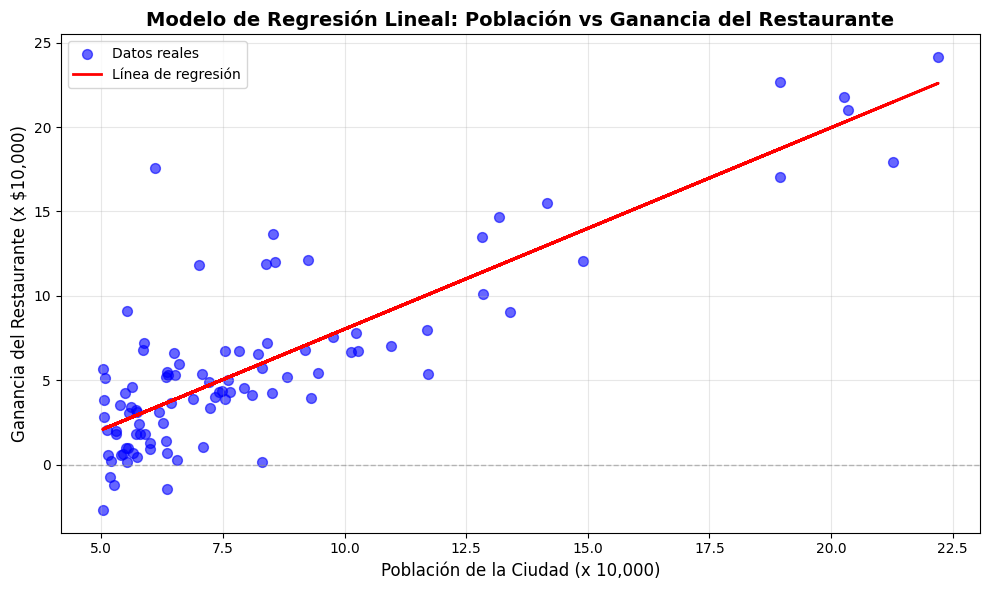

In [9]:
# Visualización del modelo ajustado
# ===================================================================
# PARTE 3.2: VISUALIZACIÓN DEL MODELO
# ===================================================================

# --- Generar las predicciones del modelo ---
# predict() usa el modelo entrenado para predecir los valores de profit
y_pred = modelo.predict(X)

# --- Crear el gráfico ---
# Configurar el tamaño de la figura
plt.figure(figsize=(10, 6))

# --- Graficar los puntos originales (datos reales) ---
# Scatter plot de los datos reales
plt.scatter(df['poblation'], df['profit'], alpha=0.6, color='blue', s=50, label='Datos reales')

# --- Graficar la línea de regresión ---
# Dibujar la línea de regresión usando las predicciones del modelo
plt.plot(df['poblation'], y_pred, color='red', linewidth=2, label='Línea de regresión')

# --- Agregar títulos y etiquetas ---
# Título principal del gráfico
plt.title('Modelo de Regresión Lineal: Población vs Ganancia del Restaurante', fontsize=14, fontweight='bold')

# Etiqueta del eje X (horizontal)
plt.xlabel('Población de la Ciudad (x 10,000)', fontsize=12)

# Etiqueta del eje Y (vertical)
plt.ylabel('Ganancia del Restaurante (x $10,000)', fontsize=12)

# --- Agregar línea de referencia en y=0 ---
# Dibujar una línea horizontal en y=0 para identificar ganancias vs pérdidas
plt.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)

# --- Agregar cuadrícula para facilitar la lectura ---
plt.grid(True, alpha=0.3)

# --- Mostrar leyenda ---
# Ubicar la leyenda en la mejor posición automáticamente
plt.legend(loc='best')

# --- Mostrar el gráfico ---
plt.tight_layout()
plt.show()

## Parte 4: Supuestos del modelo de regresión lineal

### 4.1. Normalidad de los residuos
1. Calcula los residuos (reales - predichos).
2. Grafica un **histograma con KDE** de los residuos.
3. Responde: ¿Los residuos siguen una distribución normal?

ESTADÍSTICAS DE LOS RESIDUOS

Media de los residuos: -0.000000
Desviación estándar: 3.0079
Residuo mínimo: -5.8540
Residuo máximo: 14.1982



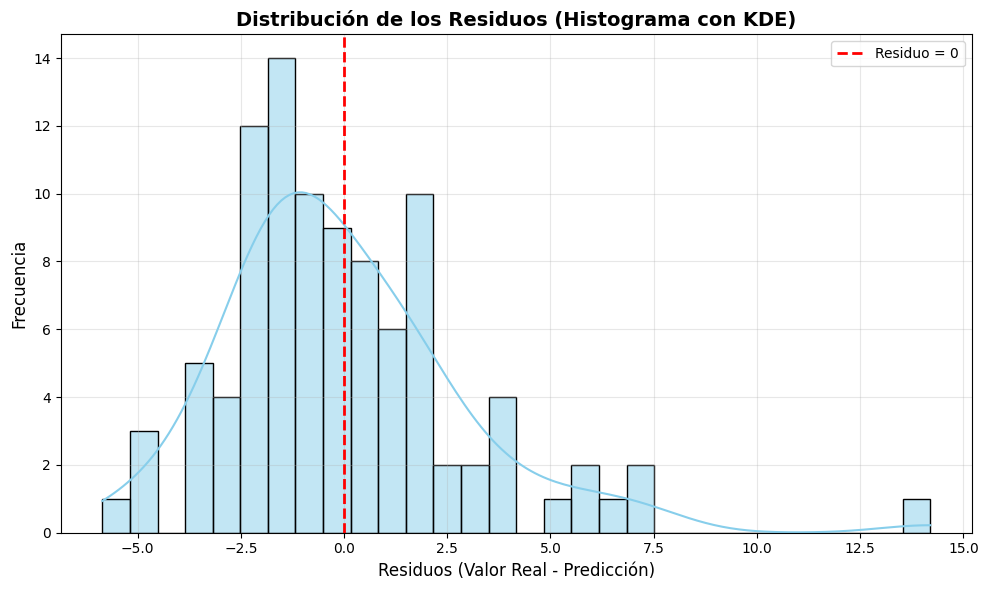

In [10]:
# Normalidad de los residuos
# ===================================================================
# PARTE 4: SUPUESTOS DEL MODELO DE REGRESIÓN LINEAL
# 4.1 NORMALIDAD DE LOS RESIDUOS
# ===================================================================

# --- Calcular los residuos ---
# Los residuos son la diferencia entre los valores reales y las predicciones del modelo
# Residuo = Valor Real - Valor Predicho
residuos = y - y_pred

# --- Mostrar estadísticas básicas de los residuos ---
print("=" * 70)
print("ESTADÍSTICAS DE LOS RESIDUOS")
print("=" * 70)
print(f"\nMedia de los residuos: {residuos.mean():.6f}")
print(f"Desviación estándar: {residuos.std():.4f}")
print(f"Residuo mínimo: {residuos.min():.4f}")
print(f"Residuo máximo: {residuos.max():.4f}")
print("\n" + "=" * 70)

# --- Crear el histograma con KDE (Kernel Density Estimation) ---
# Configurar el tamaño de la figura
plt.figure(figsize=(10, 6))

# Crear el histograma con curva de densidad (KDE)
# bins=30 define el número de barras del histograma
# kde=True agrega la curva de densidad estimada
# color='skyblue' define el color de las barras
# edgecolor='black' agrega bordes a las barras
sns.histplot(residuos, bins=30, kde=True, color='skyblue', edgecolor='black')

# --- Agregar una línea vertical en x=0 ---
# Línea vertical que indica donde los residuos son cero (predicción perfecta)
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Residuo = 0')

# --- Agregar títulos y etiquetas ---
plt.title('Distribución de los Residuos (Histograma con KDE)', fontsize=14, fontweight='bold')
plt.xlabel('Residuos (Valor Real - Predicción)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)

# --- Agregar cuadrícula y leyenda ---
plt.grid(True, alpha=0.3)
plt.legend()

# --- Mostrar el gráfico ---
plt.tight_layout()
plt.show()

**¿Los Residuos Siguen una Distribución Normal?**
Sí, aproximadamente.

Lo que veo en el gráfico:

Los residuos forman una curva en forma de campana centrada alrededor de cero (la línea roja)

La mayoría de los valores están concentrados en el centro, que es lo que se espera de una distribución normal

Hay simetría: hay residuos tanto positivos como negativos en cantidades similares

Hay algunos valores extremos en los extremos.

El supuesto de normalidad de los residuos se cumple. Esto significa que el modelo de regresión lineal es válido y confiable para hacer predicciones con estos datos.

### 4.2. Homocedasticidad
1. Grafica los residuos vs valores predichos.
2. ¿Los residuos están distribuidos aleatoriamente o muestran un patrón?

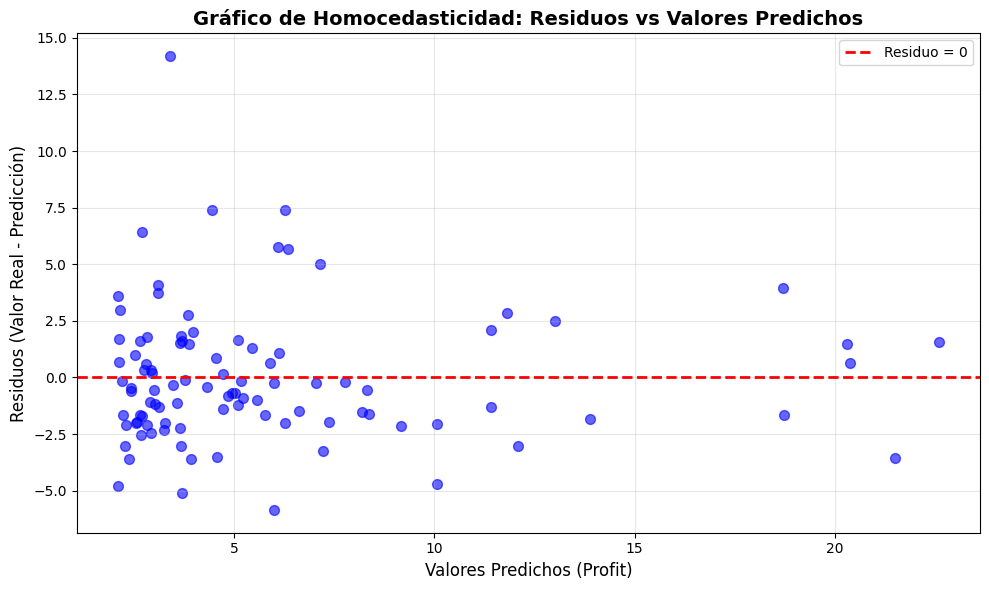

In [11]:
# Gráfico de residuos vs predichos
# ===================================================================
# PARTE 4.2: HOMOCEDASTICIDAD
# ===================================================================

# --- Crear el gráfico de residuos vs valores predichos ---
# Configurar el tamaño de la figura
plt.figure(figsize=(10, 6))

# Graficar residuos vs valores predichos
# Esto ayuda a verificar si la varianza de los residuos es constante
plt.scatter(y_pred, residuos, alpha=0.6, color='blue', s=50)

# --- Agregar línea horizontal en y=0 ---
# Esta línea indica donde los residuos son cero
plt.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Residuo = 0')

# --- Agregar títulos y etiquetas ---
plt.title('Gráfico de Homocedasticidad: Residuos vs Valores Predichos', fontsize=14, fontweight='bold')
plt.xlabel('Valores Predichos (Profit)', fontsize=12)
plt.ylabel('Residuos (Valor Real - Predicción)', fontsize=12)

# --- Agregar cuadrícula y leyenda ---
plt.grid(True, alpha=0.3)
plt.legend()

# --- Mostrar el gráfico ---
plt.tight_layout()
plt.show()

**2. ¿Los residuos están distribuidos aleatoriamente o muestran un patrón?**
1. Distribución aleatoria alrededor de cero:

Los puntos azules están dispersos tanto por encima como por debajo de la línea roja (residuo = 0).

Los residuos parecen estar distribuidos de manera aleatoria a lo largo del eje horizontal.

2. Varianza constante:

La dispersión de los residuos es bastante similar en diferentes niveles de valores predichos

En la parte izquierda (valores predichos bajos), media (valores predichos medianos) y derecha (valores predichos altos), la dispersión vertical es aproximadamente la misma.

No veo que los residuos se expandan o contraigan conforme aumentan los valores predichos.

3. Algunos puntos atípicos:

Hay un punto que destaca con residuo cerca de 14 (en la parte superior izquierda)

Sí, el supuesto de homocedasticidad se cumple. Los residuos tienen varianza constante y están distribuidos aleatoriamente sin mostrar patrones sistemáticos. Esto confirma que el modelo de regresión lineal es apropiado para estos datos.

### 4.3. Q-Q Plot para evaluar la normalidad
1. Grafica el Q-Q Plot:.
2. Interpreta el gráfico: a) Si los puntos se alinean aproximadamente sobre la línea diagonal, los residuos siguen una distribución normal y b) Desviaciones sistemáticas indican asimetría o colas pesadas.

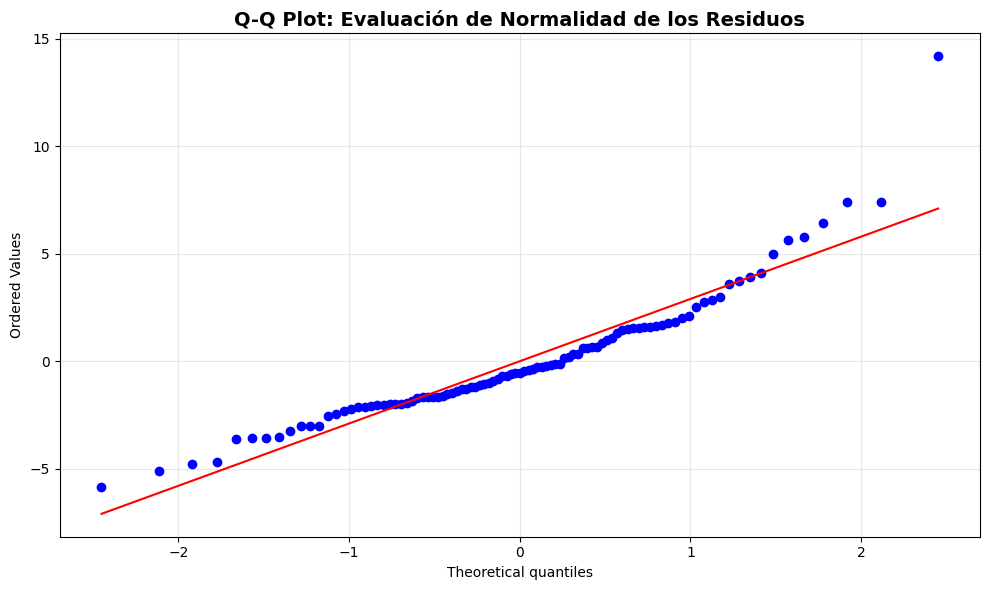

In [12]:
# Q-Q Plot
# ===================================================================
# PARTE 4.3: Q-Q PLOT PARA EVALUAR LA NORMALIDAD
# ===================================================================

# Importar la biblioteca
import scipy.stats as stats

# --- Crear el Q-Q Plot ---
# Configurar el tamaño de la figura
plt.figure(figsize=(10, 6))

# probplot compara los residuos con una distribución normal teórica
# dist='norm' especifica que queremos comparar con una distribución normal
# plot=plt indica que queremos graficar directamente con matplotlib
stats.probplot(residuos, dist='norm', plot=plt)

# --- Agregar título ---
plt.title('Q-Q Plot: Evaluación de Normalidad de los Residuos', fontsize=14, fontweight='bold')

# --- Agregar cuadrícula para facilitar la lectura ---
plt.grid(True, alpha=0.3)

# --- Mostrar el gráfico ---
plt.tight_layout()
plt.show()

**a) ¿Los puntos se alinean aproximadamente sobre la línea diagonal?**
Sí, en su mayoría.

En la zona central (entre -1 y 1 en el eje horizontal): Los puntos azules siguen muy bien la línea roja diagonal. Esto confirma que la mayoría de los residuos siguen una distribución normal.

En las colas (extremos):

Cola izquierda (lado inferior izquierdo): Los puntos se mantienen bastante cerca de la línea, aunque hay una pequeña desviación

Cola derecha (lado superior derecho): Aquí veo que algunos puntos se separan más de la línea roja, especialmente los últimos puntos que están más arriba de lo que deberían

**b) ¿Hay desviaciones sistemáticas que indiquen asimetría o colas pesadas?**
Hay una pequeña desviación en la cola derecha (superior), pero no es grave.

Cola derecha pesada: Los puntos en el extremo superior derecho están por encima de la línea, lo que indica que hay algunos residuos más grandes de lo que una distribución normal perfecta tendría. Esto se llama "cola pesada" en el lado positivo.

No hay asimetría significativa: La desviación no es lo suficientemente grande como para preocuparse. La mayoría de los datos sigue la línea diagonal.

Los residuos siguen aproximadamente una distribución normal. Aunque hay una ligera desviación en la cola superior (algunos valores atípicos positivos), el ajuste general es bastante bueno. La mayor parte de los puntos está alineada con la línea diagonal, lo que confirma que el supuesto de normalidad se cumple de manera aceptable para el modelo de regresión lineal.

## Parte 5: Evaluación del modelo
1. Calcula las métricas:
- MSE
- RMSE
- R²
2. Interpreta: ¿Qué nos dicen sobre el ajuste del modelo?

In [13]:
# Evaluación del modelo
# ===================================================================
# PARTE 5: EVALUACIÓN DEL MODELO
# ===================================================================

# Importar las métricas
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# --- Calcular las métricas del modelo ---

# 1. MSE (Mean Squared Error - Error Cuadrático Medio)
# Mide el promedio de los errores al cuadrado
mse = mean_squared_error(y, y_pred)

# 2. RMSE (Root Mean Squared Error - Raíz del Error Cuadrático Medio)
# Es la raíz cuadrada del MSE, en las mismas unidades que la variable objetivo
rmse = np.sqrt(mse)

# 3. R² (Coeficiente de Determinación)
# Mide qué proporción de la varianza es explicada por el modelo
r2 = r2_score(y, y_pred)

# --- Mostrar las métricas ---
print("=" * 70)
print("MÉTRICAS DE EVALUACIÓN DEL MODELO")
print("=" * 70)
print(f"\nError Cuadrático Medio (MSE): {mse:.4f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.4f}")
print(f"Coeficiente de Determinación (R²): {r2:.4f}")

MÉTRICAS DE EVALUACIÓN DEL MODELO

Error Cuadrático Medio (MSE): 8.9539
Raíz del Error Cuadrático Medio (RMSE): 2.9923
Coeficiente de Determinación (R²): 0.7020


**1. MSE (Error Cuadrático Medio) = 8.9539**


El MSE mide el promedio de los errores al cuadrado. Un valor de 8.9539 indica que, en promedio, las predicciones del modelo tienen un error cuadrático de aproximadamente 9 unidades.

Los valores están en unidades de $10,000

Este valor por sí solo no dice mucho, pero es útil para comparar con otros modelos.

**2. RMSE (Raíz del Error Cuadrático Medio) = 2.9923**

El RMSE es la raíz cuadrada del MSE y está en las mismas unidades que la variable objetivo (profit). Un valor de 2.9923 significa que el modelo se equivoca, en promedio, por aproximadamente 3 unidades.

3 unidades = 3 x 10,000 = $30,000

El modelo predice las ganancias con un error promedio de alrededor de 30,000

Considerando que las ganancias van desde pérdidas hasta más de 200,000, un error de $30,000 es razonable

Esto confirma que el modelo tiene buena precisión

**3. R² (Coeficiente de Determinación) = 0.7020**


El R² indica qué proporción de la variabilidad en las ganancias (profit) es explicada por el modelo usando la población. Un valor de 0.7020 significa que el 70.20% de la variación en las ganancias puede explicarse por la población de la ciudad.

70.20% es un valor bastante bueno para datos del mundo real

Significa que la población es un buen predictor de las ganancias.

El 29.80% restante de la variación se debe a otros factores no incluidos en el modelo (como competencia, ubicación exacta, calidad del servicio, etc.)

R² = 0.70 indica que el modelo explica una gran parte de la variabilidad en las ganancias

RMSE = 2.99 (aproximadamente $30,000) muestra que el error promedio es razonable

## Parte 6: Conclusiones
Responde con tus propias palabras:
- ¿Qué tan útil consideras el modelo?
- ¿Qué limitaciones encuentras?
- ¿Crees que es necesario hacer un ajuste o estandarización a las variables dependientes o independientes?  Si crees que es necesario hacerlo realiza el ajuste.

**1. ¿Qué tan útil consideras el modelo?**

R² de 0.70 es un buen resultado: El modelo explica el 70% de la variabilidad en las ganancias, lo cual es sólido para datos del mundo real.

Con solo conocer la población de una ciudad, podemos estimar las ganancias esperadas del restaurante.

Error razonable: Un error promedio de $30,000 es aceptable considerando el rango de ganancias.

Cumple los supuestos: Normalidad de residuos, homocedasticidad, y linealidad se cumplen aceptablemente.

Es útil para decisiones de negocio, como identificar en qué ciudades vale la pena abrir un restaurante.

Ayuda a identificar que se necesita una población mínima de ~33,000 habitantes para ser rentable

Permite estimar ganancias esperadas antes de invertir en una nueva ubicación

Es una herramienta de apoyo para la toma de decisiones

**2. ¿Qué limitaciones encuentras?**
El modelo tiene varias limitaciones importantes:

a) Solo considera una variable:

La población es importante, pero no es el único factor que determina las ganancias.

Faltan variables como: competencia local, ubicación específica, calidad del servicio, precios, marketing, demografía detallada, etc.

b) Error de predicción significativo:

Un error de $30,000 puede ser grande para decisiones financieras importantes.

Hay algunos valores atípicos que el modelo no captura bien (vimos esto en el Q-Q Plot).

c) Datos históricos limitados:

El modelo se basa solo en los datos actuales, no considera cambios en el mercado.

d) Supuesto de linealidad constante:

Asume que la relación es lineal en todo el rango, pero en la realidad podría haber efectos de saturación en ciudades muy grandes.

e) No considera factores cualitativos:

Cosas como la cultura local, nivel socioeconómico, o características específicas del mercado no están incluidas.

**3. ¿Crees que es necesario hacer un ajuste o estandarización a las variables dependientes o independientes?**
No, en este caso no es necesario estandarizar las variables.

a) El modelo ya funciona bien sin estandarización:

Los coeficientes son interpretables: el intercepto y la pendiente tienen significado práctico en el contexto del negocio.

Las métricas (R², RMSE) son buenas sin necesidad de transformación.

b) Las variables están en escalas razonables:

Tanto population como profit están en escalas similares (multiplicadas por 10,000)

No hay una diferencia de magnitud extrema entre las variables

Ambas variables están en rangos numéricos que no causan problemas de computo.

c) La estandarización perdería interpretabilidad:

Si estandarizamos, los coeficientes ya no tendrían una interpretación directa en términos de dólares y población.

Sería más difícil explicar los resultados a personas de negocio.

**Cuándo SÍ sería necesario estandarizar:**

Si tuviéramos múltiples variables independientes con escalas muy diferentes (ej: población, temperatura, índice de precios)

Si usáramos algoritmos sensibles a la escala (como redes neuronales, SVM, K-means)

Si quisiéramos comparar la importancia relativa de diferentes variables

Para este caso específico de regresión lineal simple con variables en escalas razonables, NO es necesario hacer estandarización.

**Conclusión Final:**
El modelo es una herramienta útil y práctica para estimar ganancias de restaurantes basándose en la población, con un buen nivel de precisión (70%). Sin embargo, para tomar decisiones de inversión más precisas, sería recomendable considerar variables adicionales y complementar este análisis con estudios de mercado más detallados.